In this notebook, we perform the changeoint analysis proposed by Fiedler, et al., 2018

Reference:
Fiedler, Hainzl, Zöller & Holschneider, Detection of Gutenberg–Richter, "b-Value Changes in Earthquake Time Series", BSSA, 108 (5A), 2778–2787, 2018

In [40]:
from seismostats.analysis import ClassicBValueEstimator, BPositiveBValueEstimator, estimate_mc_maxc
from seismostats.utils import simulate_magnitudes_binned
from seismostats.plots import plot_fmd, plot_cum_fmd
from functions.determine_changepoint import findCP_bvalues
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import warnings

%config InlineBackend.figure_format ='retina'


In [41]:
DIR = Path("data")
variables_df = pd.read_csv(DIR / "variables.csv")
variables = variables_df.to_dict(orient="records")[0]

RESULT_DIR = Path("results/sequence_csv")
DELTA_M = variables["DELTA_M"] 
MC_FIXED = variables["MC_FIXED"]
DMC = variables["DMC"]
CORRECTION_FACTOR = variables["CORRECTION_FACTOR"]
num_seqs = 62

In [42]:
# load sequences
dfs = []

for i in range(1, num_seqs + 1):
    file_path = RESULT_DIR / f"sequence_{i}.csv"
    df = pd.read_csv(file_path)
    dfs.append(df)

In [43]:
cleaned_dfs = []

for df in dfs:
    df = df.copy()

    # find main event
    main_rows = df[df["is_main_event"] == True]
    main_time = main_rows.iloc[0].time

    # keep only events BEFORE main event in time
    df_clean = df[
        (df["time"] < main_time) & (~df["is_main_event"])
    ].copy()

    cleaned_dfs.append(df_clean)

i=0   n=1050  SUM1=0.000000
i=0   n=1253  SUM1=0.000000
sequence 8:

	 1 Change-points found

Legend added to the plot.
Legend added to the plot.


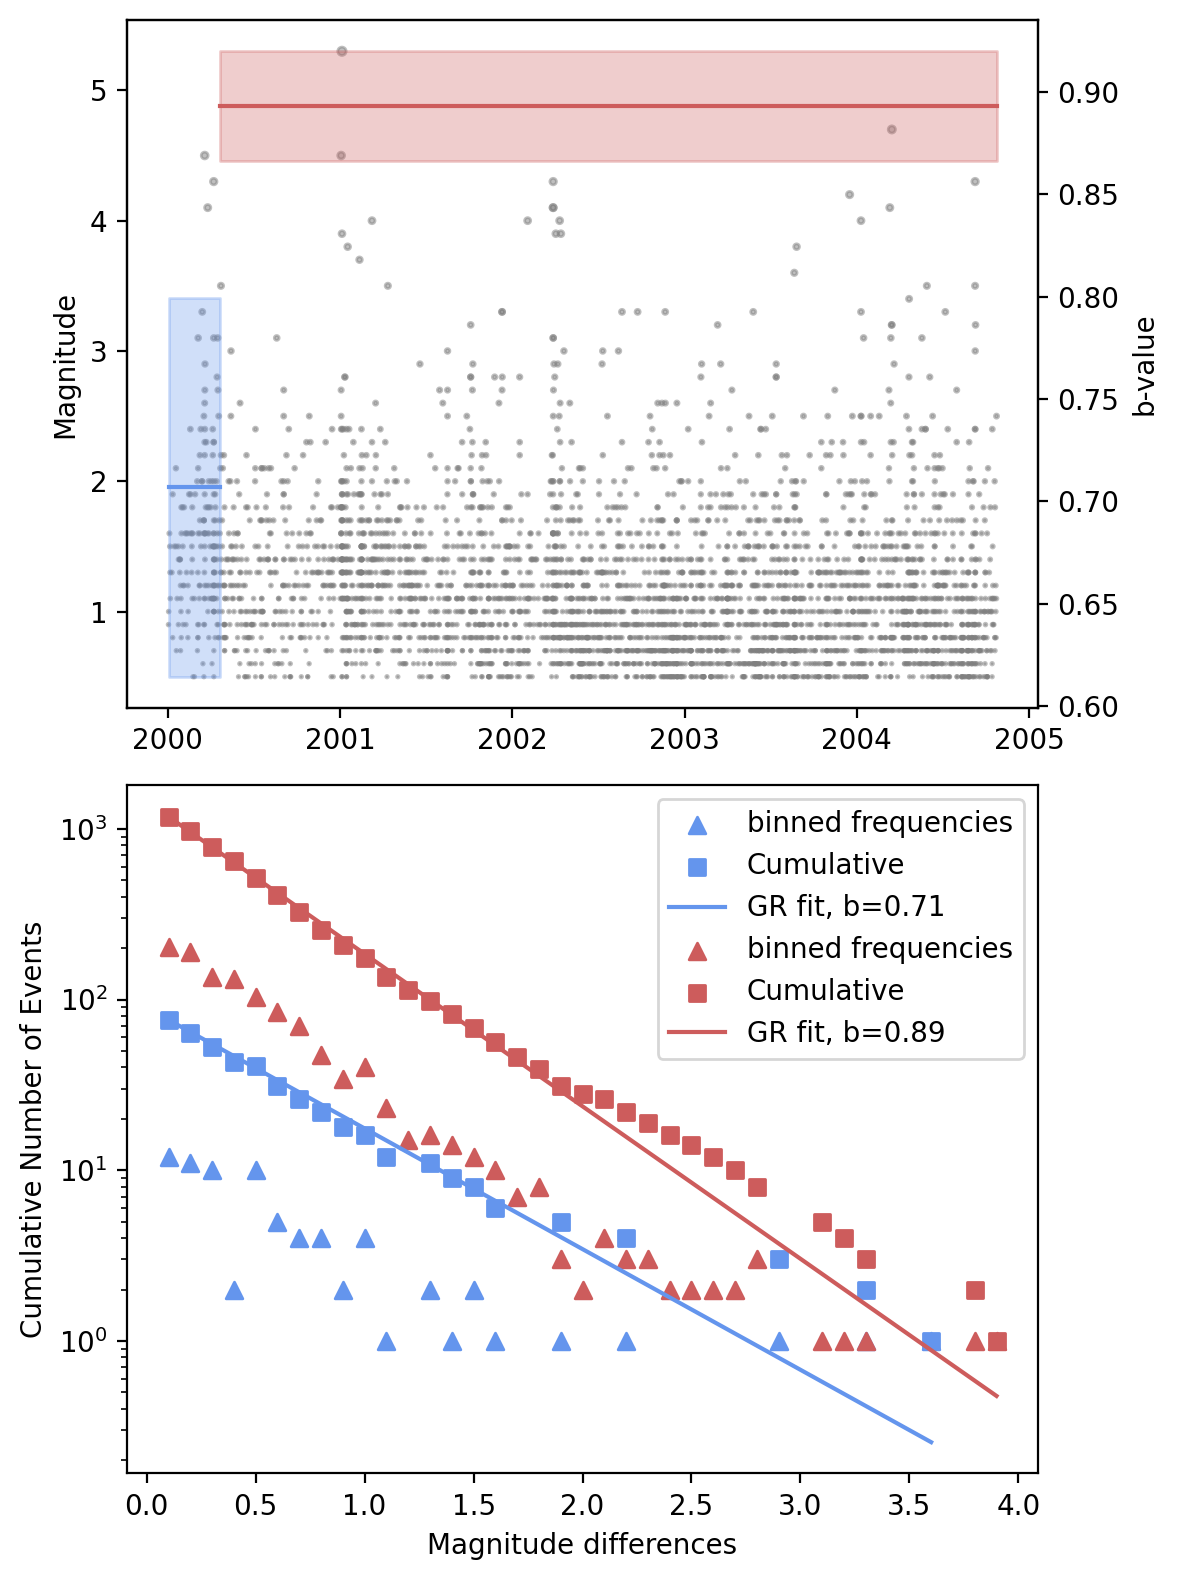

i=689   n=692  SUM2=0.000000
i=690   n=692  SUM2=0.000000
i=0   n=260  SUM1=0.000000
sequence 12:

	 1 Change-points found

Legend added to the plot.
Legend added to the plot.


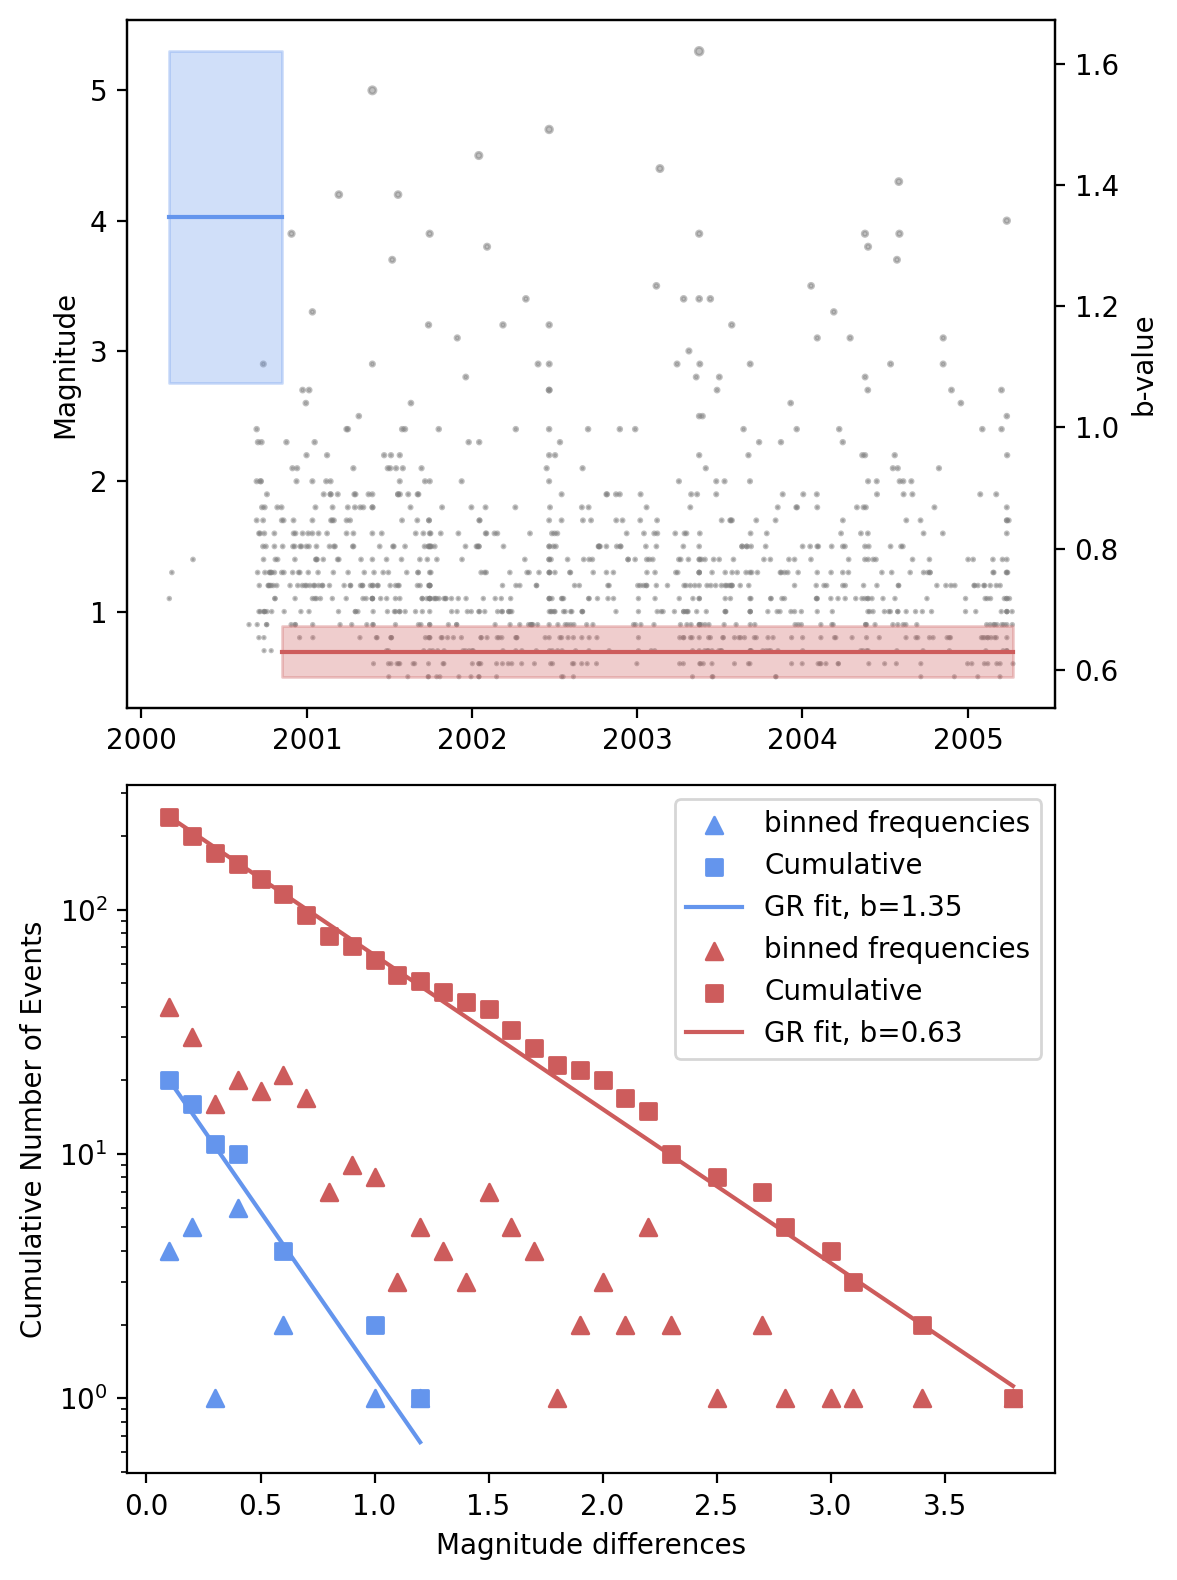

sequence 13:

	 1 Change-points found

Legend added to the plot.
Legend added to the plot.


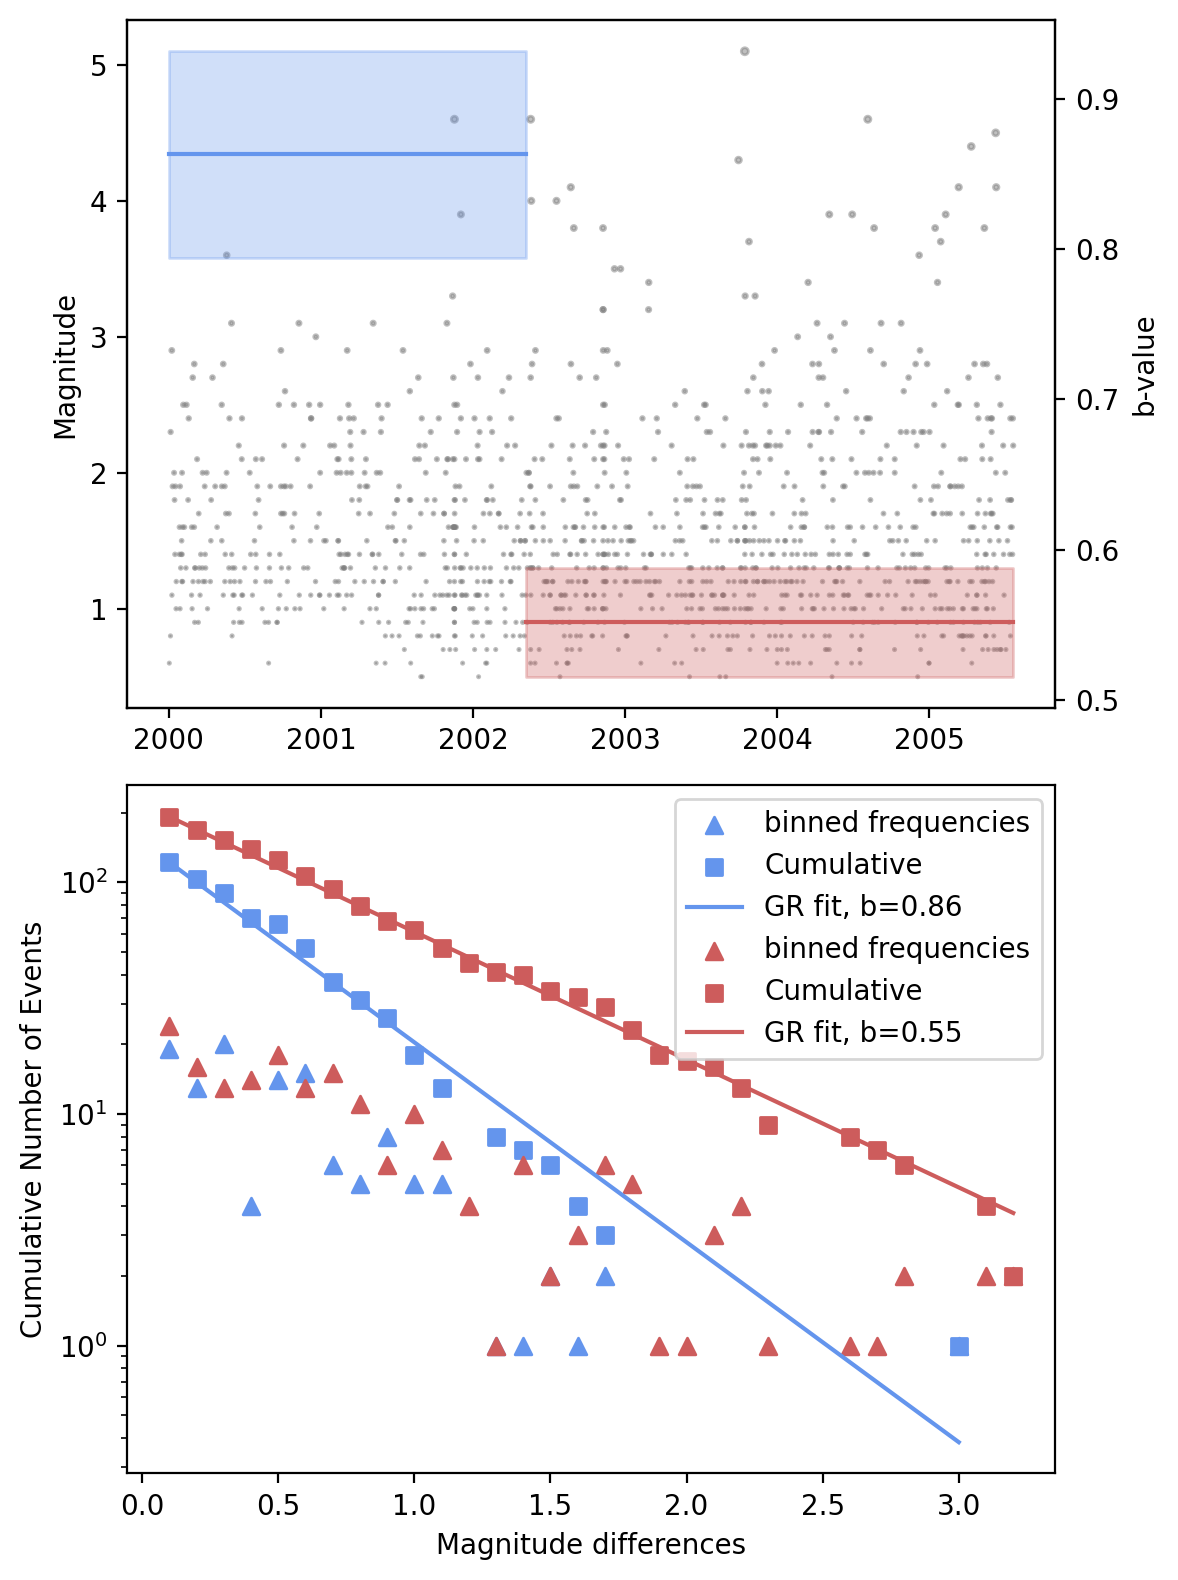

i=0   n=210  SUM1=0.000000
sequence 18:

	 1 Change-points found

Legend added to the plot.
Legend added to the plot.


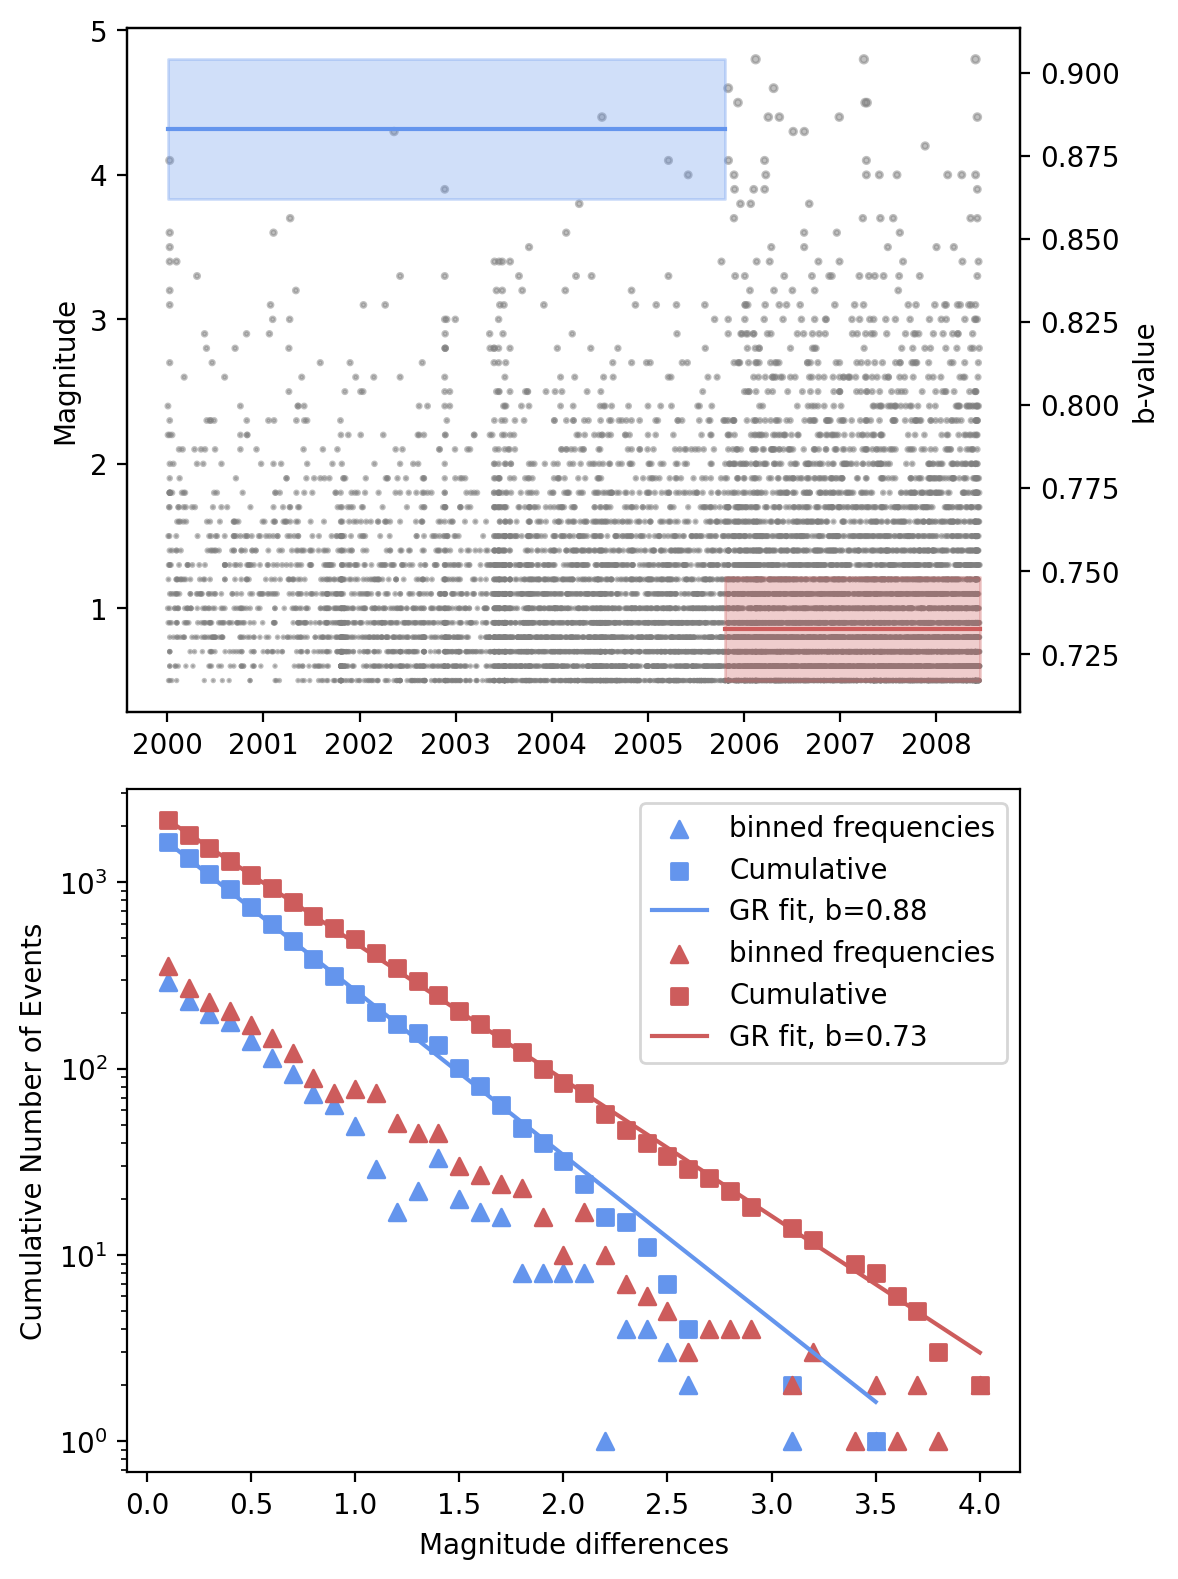

i=259   n=261  SUM2=0.000000
i=0   n=22  SUM1=0.000000
sequence 35:

	 1 Change-points found

Legend added to the plot.
Legend added to the plot.


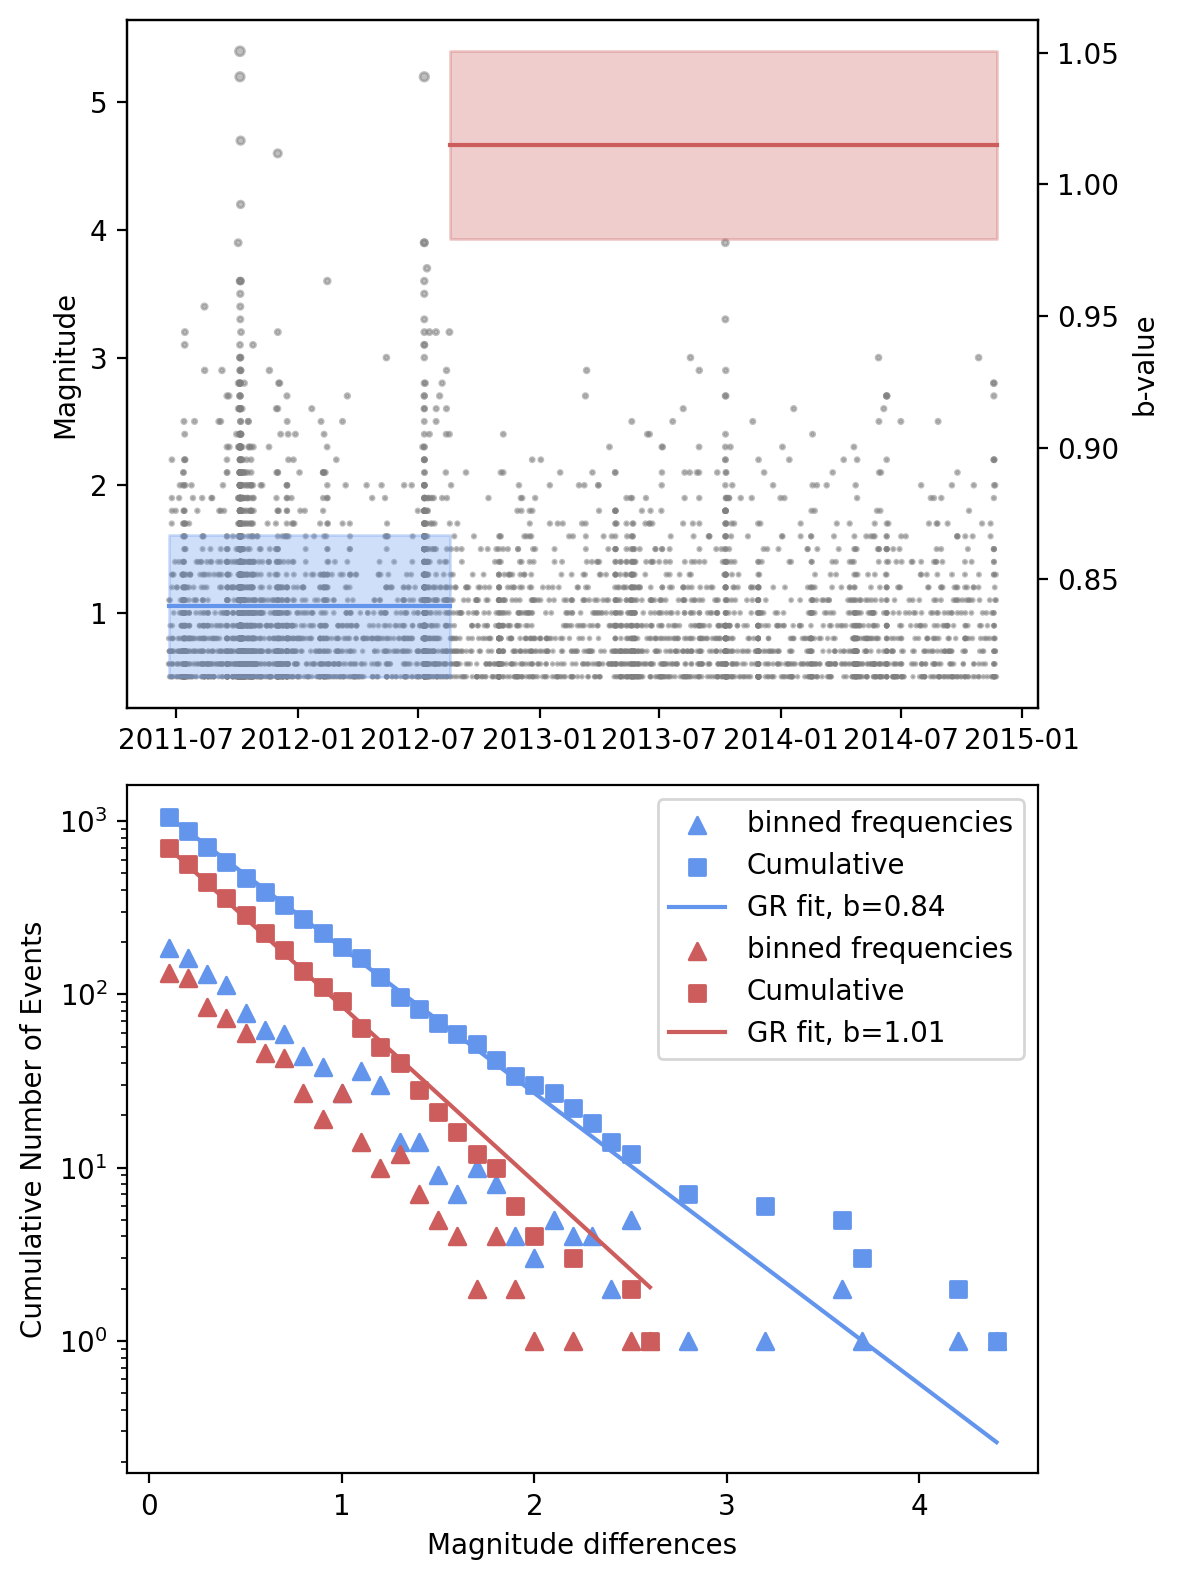

i=1720   n=1723  SUM2=0.000000
i=1721   n=1723  SUM2=0.000000
i=0   n=518  SUM1=0.000000
i=516   n=518  SUM2=0.000000
i=781   n=783  SUM2=0.000000
i=0   n=152  SUM1=0.000000
i=150   n=152  SUM2=0.000000
i=0   n=10336  SUM1=0.000000
sequence 52:

	 1 Change-points found

Legend added to the plot.
Legend added to the plot.


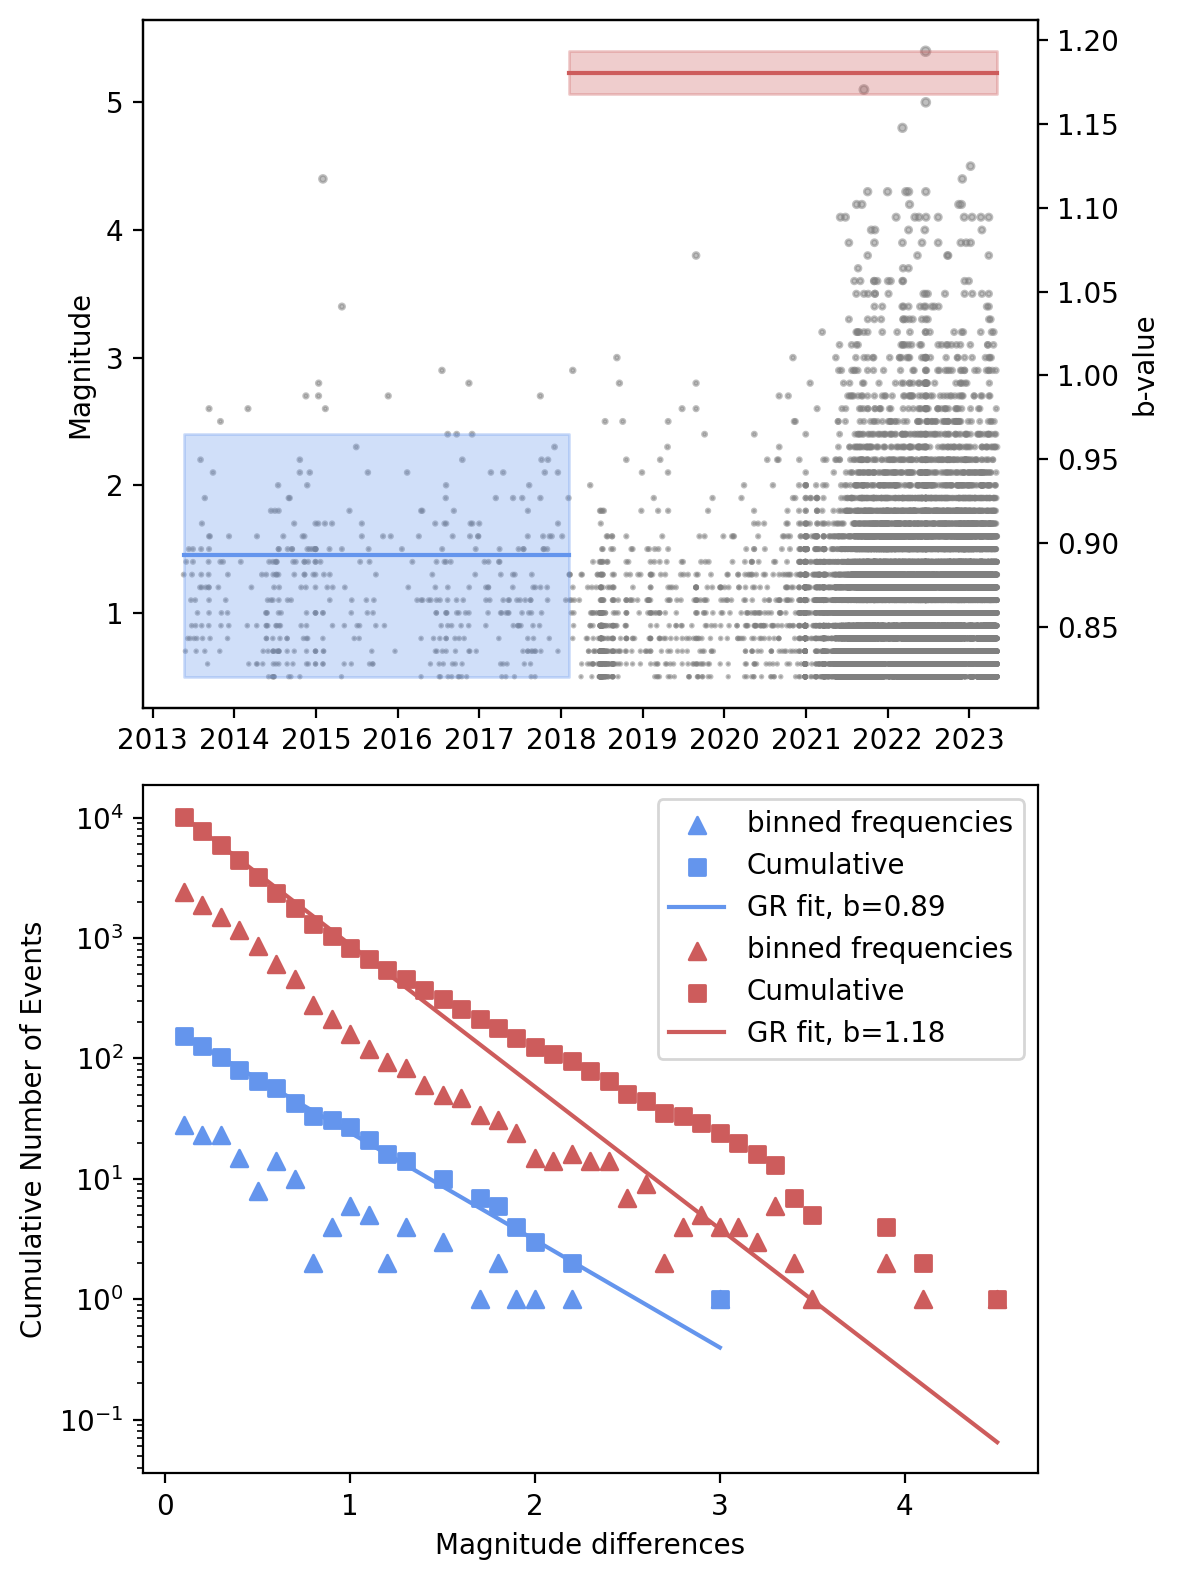

sequence 53:

	 1 Change-points found

Legend added to the plot.
Legend added to the plot.


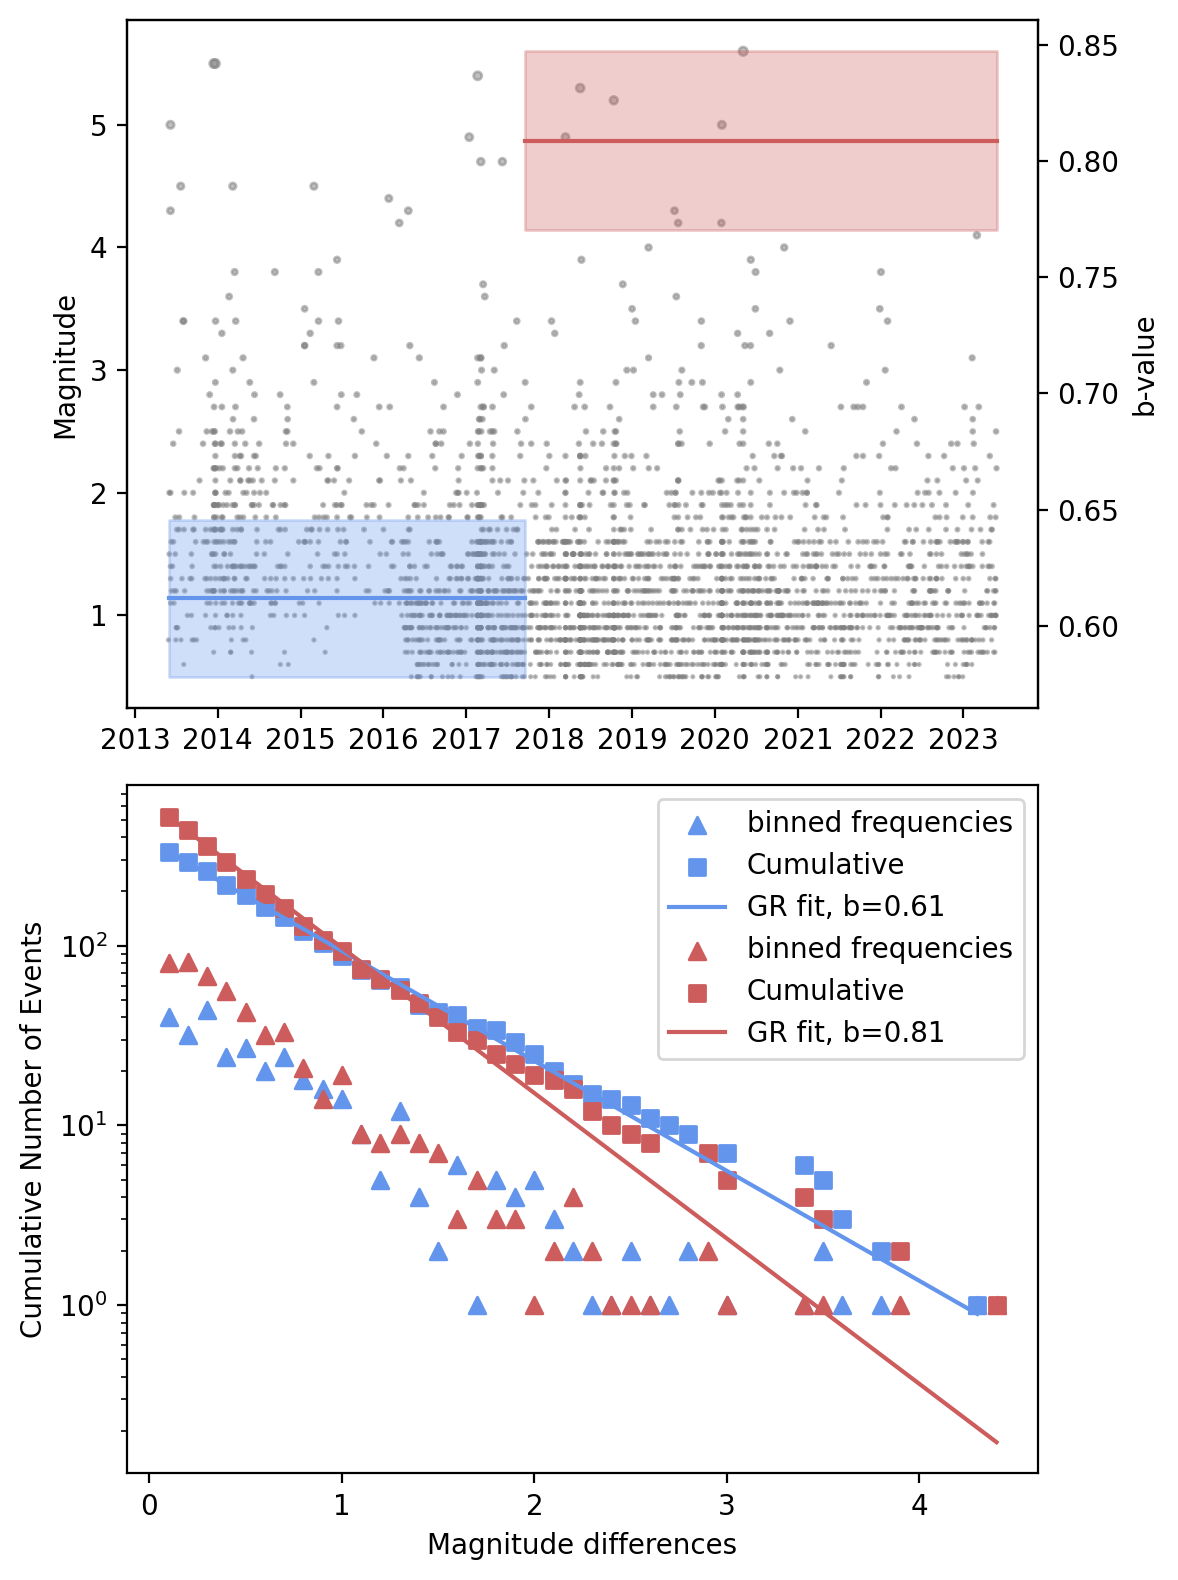

sequence 55:

	 1 Change-points found

Legend added to the plot.
Legend added to the plot.


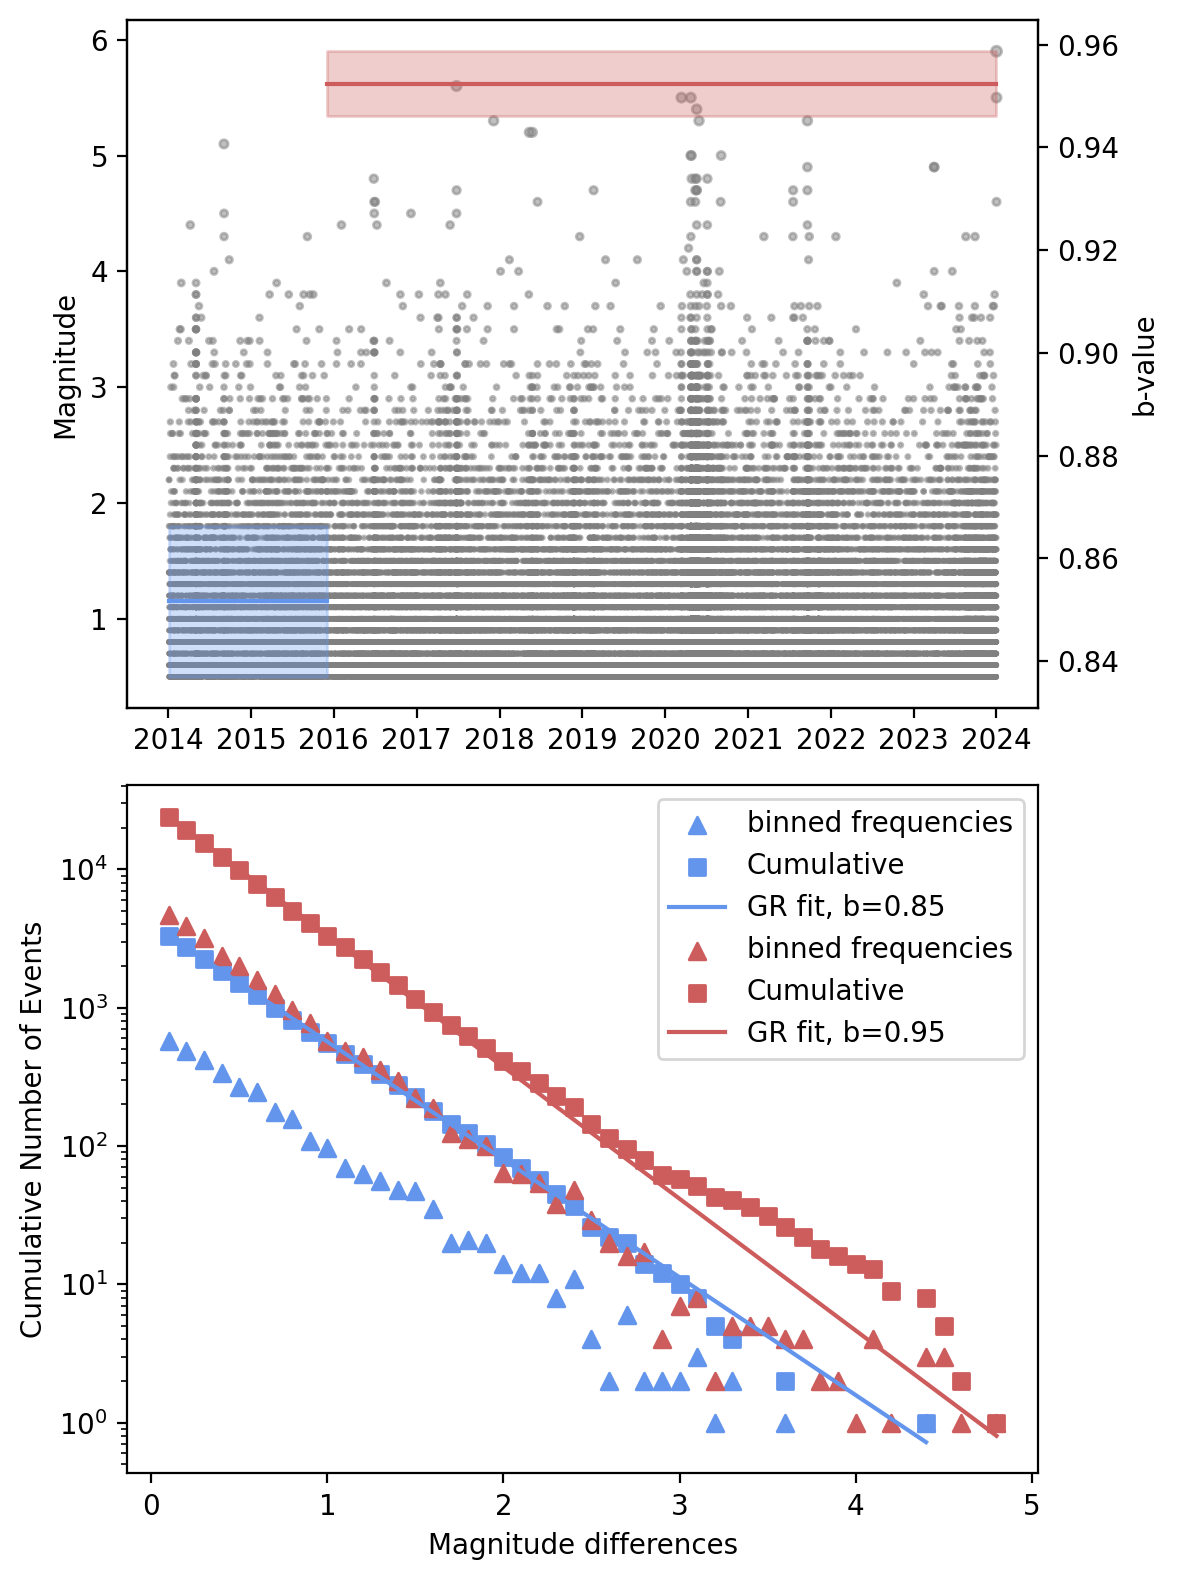

i=2646   n=2649  SUM2=0.000000
i=2647   n=2649  SUM2=0.000000


In [ ]:
results = []

# suppress warnings
warnings.filterwarnings('ignore')

for ii, df in enumerate(cleaned_dfs):
    m = df["magnitude"].values
    t = pd.to_datetime(df["time"], format='mixed')

    # estimate completeness
    if len(m) < 100:
        continue
    mc, _ = estimate_mc_maxc(m, fmd_bin = 0.1, correction_factor = CORRECTION_FACTOR)

    # only consider positive differences
    estimator = BPositiveBValueEstimator()
    estimator.calculate(m, mc=mc, delta_m=DELTA_M, dmc=DMC)
    m_ind = estimator.idx
    m_pos = estimator.magnitudes

    # estimate change points:
    chps = [findCP_bvalues(m_pos - DELTA_M)]
    if not np.isnan(chps[0]):
        print("sequence %d:" % (ii))
        chps = np.asarray(chps, dtype=int)
        ncs  = len(chps)
        m_best = chps[0]

        estimator.calculate(m[:m_ind[m_best]], mc=mc, delta_m=DELTA_M, dmc=DMC)
        b1 = estimator.b_value
        b1_std = estimator.std

        estimator.calculate(m[m_ind[m_best]:], mc=mc, delta_m=DELTA_M, dmc=DMC)
        b2 = estimator.b_value
        b2_std = estimator.std

        print('\n\t %d Change-points found\n' % (ncs))

        # --- CREATE FIGURE WITH 2 SUBPLOTS ---
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 8))

        # --- TOP PLOT (your original) ---
        ax1.scatter(t, m, c='gray', s=np.exp(0.5*(m-mc)), alpha=0.5)
        ax1.set_ylabel('Magnitude')

        ax1b = ax1.twinx()
        ax1b.plot(
            [t.iloc[0], t.iloc[m_ind[m_best]]],
            [b1, b1],
            c='cornflowerblue'
        )
        ax1b.plot(
            [t.iloc[m_ind[m_best]], t.iloc[-1]],
            [b2, b2],
            c='indianred'
        )
        ax1b.fill_between(
            [t.iloc[0], t.iloc[m_ind[m_best]]],
            [b1+b1_std, b1+b1_std],
            [b1-b1_std, b1-b1_std],
            color='cornflowerblue', alpha=0.3
        )
        ax1b.fill_between(
            [t.iloc[m_ind[m_best]], t.iloc[-1]],
            [b2+b2_std, b2+b2_std],
            [b2-b2_std, b2-b2_std],
            color='indianred', alpha=0.3
        )
        ax1b.set_ylabel('b-value')

        # --- BOTTOM PLOT (NEW) ---
        # Example: cumulative number of events
        plot_fmd(m_pos[:m_best],fmd_bin=0.1, ax=ax2, color='cornflowerblue', label='binned frequencies')
        plot_cum_fmd(m_pos[:m_best], ax=ax2, color='cornflowerblue', label='Cumulative', mc=DELTA_M, b_value =b1,)
        plot_fmd(m_pos[m_best:],fmd_bin=0.1, ax=ax2, color='indianred', label='binned frequencies')
        plot_cum_fmd(m_pos[m_best:], ax=ax2, color='indianred', label='Cumulative', mc=DELTA_M, b_value =b2,)
        ax2.set_xlabel('Magnitude differences')
        ax2.set_ylabel('Cumulative Number of Events')
        ax2.legend()

        # formatting
        plt.xticks(rotation=45)
        plt.tight_layout()

        # save
        plt.savefig(RESULT_DIR / f"images/sequence_{ii+1}.png", dpi=300, bbox_inches='tight')
        plt.show()

        results.append({
            "sequence": ii + 1,
            "change_point": chps[0],
            "b1": b1,
            "b1_std": b1_std,
            "b2": b2,
            "b2_std": b2_std
        })

# show warnings
warnings.filterwarnings('default')

## Now, the corresponding synthetic test

In [ ]:
results_H3 = []

# suppress warnings
warnings.filterwarnings('ignore')

for ii, df in enumerate(cleaned_dfs):
    N = len(df)
    b1 = 1.1
    b2 = 0.9

    # synthetics:
    m1 = simulate_magnitudes_binned(N//2, b=b1, mc = MC_FIXED - 0.2, delta_m=0.1)
    m2 = simulate_magnitudes_binned(N - N//2, b=b2, mc = MC_FIXED - 0.2, delta_m=0.1)
    m = np.concatenate((m1, m2))
    t = pd.to_datetime(df["time"], format='mixed')

    # estimate completeness
    if len(m) < 100:
        continue
    mc, _ = estimate_mc_maxc(m, fmd_bin = 0.1, correction_factor = CORRECTION_FACTOR)

    # only consider positive differences
    estimator = BPositiveBValueEstimator()
    estimator.calculate(m, mc=mc, delta_m=DELTA_M, dmc=DMC)
    m_ind = estimator.idx
    m_pos = estimator.magnitudes

    # estimate change points:
    chps = [findCP_bvalues(m_pos - DELTA_M)]
    if not np.isnan(chps[0]):
        print("sequence %d:" % (ii))
        chps = np.asarray(chps, dtype=int)
        ncs  = len(chps)
        m_best = chps[0]

        estimator.calculate(m[:m_ind[m_best]], mc=mc, delta_m=DELTA_M, dmc=DMC)
        b1 = estimator.b_value
        b1_std = estimator.std

        estimator.calculate(m[m_ind[m_best]:], mc=mc, delta_m=DELTA_M, dmc=DMC)
        b2 = estimator.b_value
        b2_std = estimator.std

        print('\n\t %d Change-points found\n' % (ncs))

        plot_var = False
        if plot_var == True:
            # --- CREATE FIGURE WITH 2 SUBPLOTS ---
            fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 8))

            # --- TOP PLOT (your original) ---
            ax1.scatter(t, m, c='b', s=np.exp(0.5*(m-mc)), alpha=0.5)
            ax1.set_ylabel('Magnitude')

            ax1b = ax1.twinx()
            ax1b.plot(
                [t.iloc[0], t.iloc[m_ind[m_best]], t.iloc[m_ind[m_best]], t.iloc[-1]],
                [b1, b1, b2, b2],
                c='r'
            )
            ax1b.fill_between(
                [t.iloc[0], t.iloc[m_ind[m_best]], t.iloc[m_ind[m_best]], t.iloc[-1]],
                [b1+b1_std, b1+b1_std, b2+b2_std, b2+b2_std],
                [b1-b1_std, b1-b1_std, b2-b2_std, b2-b2_std],
                color='r', alpha=0.3
            )
            ax1b.set_ylabel('b-value')
            plt.xticks(rotation=45)

            # --- BOTTOM PLOT (NEW) ---
            # Example: cumulative number of events
            plot_fmd(m_pos[:m_best],fmd_bin=0.1, ax=ax2, color='cornflowerblue', label='Before Change Point')
            plot_cum_fmd(m_pos[:m_best], ax=ax2, color='cornflowerblue', label='Cumulative Before CP')
            plot_fmd(m_pos[m_best:],fmd_bin=0.1, ax=ax2, color='indianred', label='After Change Point')
            plot_cum_fmd(m_pos[m_best:], ax=ax2, color='indianred', label='Cumulative After CP')
            ax2.set_xlabel('Magnitude differences')
            ax2.set_ylabel('Cumulative Number of Events')
            ax2.legend()

            # formatting
            plt.tight_layout()

            # save
            #plt.savefig(RESULT_DIR / f"images/sequence_{ii+1}.png", dpi=300, bbox_inches='tight')
            plt.show()

        results_H3.append({
            "sequence": ii + 1,
            "change_point": chps[0],
            "b1": b1,
            "b1_std": b1_std,
            "b2": b2,
            "b2_std": b2_std
        })
        

# show warnings
warnings.filterwarnings('default')

i=0   n=75  SUM1=0.000000
i=1   n=75  SUM1=0.000000
i=73   n=75  SUM2=0.000000
i=0   n=62  SUM1=0.000000
i=100   n=103  SUM2=0.000000
i=101   n=103  SUM2=0.000000
sequence 6:

	 1 Change-points found

sequence 8:

	 1 Change-points found

i=0   n=398  SUM1=0.000000
i=1   n=398  SUM1=0.000000
sequence 12:

	 1 Change-points found

sequence 14:

	 1 Change-points found

sequence 17:

	 1 Change-points found

sequence 18:

	 1 Change-points found

i=0   n=260  SUM1=0.000000
sequence 19:

	 1 Change-points found

sequence 20:

	 1 Change-points found

sequence 27:

	 1 Change-points found

i=0   n=477  SUM1=0.000000
sequence 35:

	 1 Change-points found

sequence 36:

	 1 Change-points found

i=0   n=819  SUM1=0.000000
sequence 37:

	 1 Change-points found

sequence 38:

	 1 Change-points found

i=0   n=6889  SUM1=0.000000
sequence 39:

	 1 Change-points found

sequence 40:

	 1 Change-points found

i=0   n=341  SUM1=0.000000
sequence 42:

	 1 Change-points found

i=0   n=794  SUM1=0.00000

In [32]:
results_H0 = []

# suppress warnings
warnings.filterwarnings('ignore')

for ii, df in enumerate(cleaned_dfs):
    N = len(df)
    b1 = 1.0
    b2 = 1.0

    # synthetics:
    Mmin = 0.0
    T = 1.0
    m1 = simulate_magnitudes_binned(N//2, b=b1, mc = Mmin, delta_m=0.1)
    m2 = simulate_magnitudes_binned(N - N//2, b=b2, mc = Mmin, delta_m=0.1)
    m = np.concatenate((m1, m2))
    t = pd.to_datetime(df["time"], format='mixed')

    # only consider positive differences
    estimator = BPositiveBValueEstimator()
    estimator.calculate(m, mc=MC_FIXED, delta_m=DELTA_M, dmc=DMC)
    m_ind = estimator.idx
    m_pos = m[m_ind]

    # estimate completeness
    if len(m) < 100:
        continue
    mc, _ = estimate_mc_maxc(m, fmd_bin = 0.1, correction_factor = CORRECTION_FACTOR)

    # only consider positive differences
    estimator = BPositiveBValueEstimator()
    estimator.calculate(m, mc=mc, delta_m=DELTA_M, dmc=DMC)
    m_ind = estimator.idx
    m_pos = estimator.magnitudes

    # estimate change points:
    chps = [findCP_bvalues(m_pos - DELTA_M)]
    if not np.isnan(chps[0]):
        print("sequence %d:" % (ii))
        chps = np.asarray(chps, dtype=int)
        ncs  = len(chps)
        m_best = chps[0]

        estimator.calculate(m[:m_ind[m_best]], mc=mc, delta_m=DELTA_M, dmc=DMC)
        b1 = estimator.b_value
        b1_std = estimator.std

        estimator.calculate(m[m_ind[m_best]:], mc=mc, delta_m=DELTA_M, dmc=DMC)
        b2 = estimator.b_value
        b2_std = estimator.std

        print('\n\t %d Change-points found\n' % (ncs))

        plot_var = False
        if plot_var == True:
            # --- CREATE FIGURE WITH 2 SUBPLOTS ---
            fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 8))

            # --- TOP PLOT (your original) ---
            ax1.scatter(t, m, c='b', s=np.exp(0.5*(m-mc)), alpha=0.5)
            ax1.set_ylabel('Magnitude')

            ax1b = ax1.twinx()
            ax1b.plot(
                [t.iloc[0], t.iloc[m_ind[m_best]], t.iloc[m_ind[m_best]], t.iloc[-1]],
                [b1, b1, b2, b2],
                c='r'
            )
            ax1b.fill_between(
                [t.iloc[0], t.iloc[m_ind[m_best]], t.iloc[m_ind[m_best]], t.iloc[-1]],
                [b1+b1_std, b1+b1_std, b2+b2_std, b2+b2_std],
                [b1-b1_std, b1-b1_std, b2-b2_std, b2-b2_std],
                color='r', alpha=0.3
            )
            ax1b.set_ylabel('b-value')

            # --- BOTTOM PLOT (NEW) ---
            # Example: cumulative number of events
            plot_fmd(m_pos[:m_best],fmd_bin=0.1, ax=ax2, color='cornflowerblue', label='Before Change Point')
            plot_cum_fmd(m_pos[:m_best], ax=ax2, color='cornflowerblue', label='Cumulative Before CP')
            plot_fmd(m_pos[m_best:],fmd_bin=0.1, ax=ax2, color='indianred', label='After Change Point')
            plot_cum_fmd(m_pos[m_best:], ax=ax2, color='indianred', label='Cumulative After CP')
            ax2.set_xlabel('Magnitude differences')
            ax2.set_ylabel('Cumulative Number of Events')
            ax2.legend()

            # formatting
            plt.xticks(rotation=45)
            plt.tight_layout()

            # save
            #plt.savefig(RESULT_DIR / f"images/sequence_{ii+1}.png", dpi=300, bbox_inches='tight')
            plt.show()

        results_H0.append({
            "sequence": ii + 1,
            "change_point": chps[0],
            "b1": b1,
            "b1_std": b1_std,
            "b2": b2,
            "b2_std": b2_std
        })
        

# show warnings
warnings.filterwarnings('default')

i=0   n=641  SUM1=0.000000
sequence 11:

	 1 Change-points found

i=0   n=303  SUM1=0.000000
sequence 12:

	 1 Change-points found

i=0   n=244  SUM1=0.000000
i=3566   n=3568  SUM2=0.000000
i=592   n=594  SUM2=0.000000
i=1473   n=1475  SUM2=0.000000
i=57   n=59  SUM2=0.000000
i=0   n=56  SUM1=0.000000
sequence 33:

	 1 Change-points found

i=0   n=150  SUM1=0.000000
i=0   n=786  SUM1=0.000000
i=0   n=195  SUM1=0.000000
i=1   n=195  SUM1=0.000000
i=0   n=181  SUM1=0.000000
i=0   n=416  SUM1=0.000000
i=1   n=416  SUM1=0.000000
i=2564   n=2566  SUM2=0.000000
i=0   n=25067  SUM1=0.000000
i=0   n=491  SUM1=0.000000
i=1   n=491  SUM1=0.000000


In [33]:
print(len(results_H3), len(results_H0), len(results))

26 3 8


/var/folders/2_/2txg_9093x37rv1ls3774xkc0000gn/T/ipykernel_85818/1415133227.py:14: ResourceWarning: unclosed file <_io.BufferedReader name='results/sequence_csv/images/sequence_9.png'>
  images = [Image.open(image_path) for image_path in imgs]
/var/folders/2_/2txg_9093x37rv1ls3774xkc0000gn/T/ipykernel_85818/1415133227.py:14: ResourceWarning: unclosed file <_io.BufferedReader name='results/sequence_csv/images/sequence_13.png'>
  images = [Image.open(image_path) for image_path in imgs]
/var/folders/2_/2txg_9093x37rv1ls3774xkc0000gn/T/ipykernel_85818/1415133227.py:14: ResourceWarning: unclosed file <_io.BufferedReader name='results/sequence_csv/images/sequence_14.png'>
  images = [Image.open(image_path) for image_path in imgs]
/var/folders/2_/2txg_9093x37rv1ls3774xkc0000gn/T/ipykernel_85818/1415133227.py:14: ResourceWarning: unclosed file <_io.BufferedReader name='results/sequence_csv/images/sequence_19.png'>
  images = [Image.open(image_path) for image_path in imgs]
/var/folders/2_/2txg_

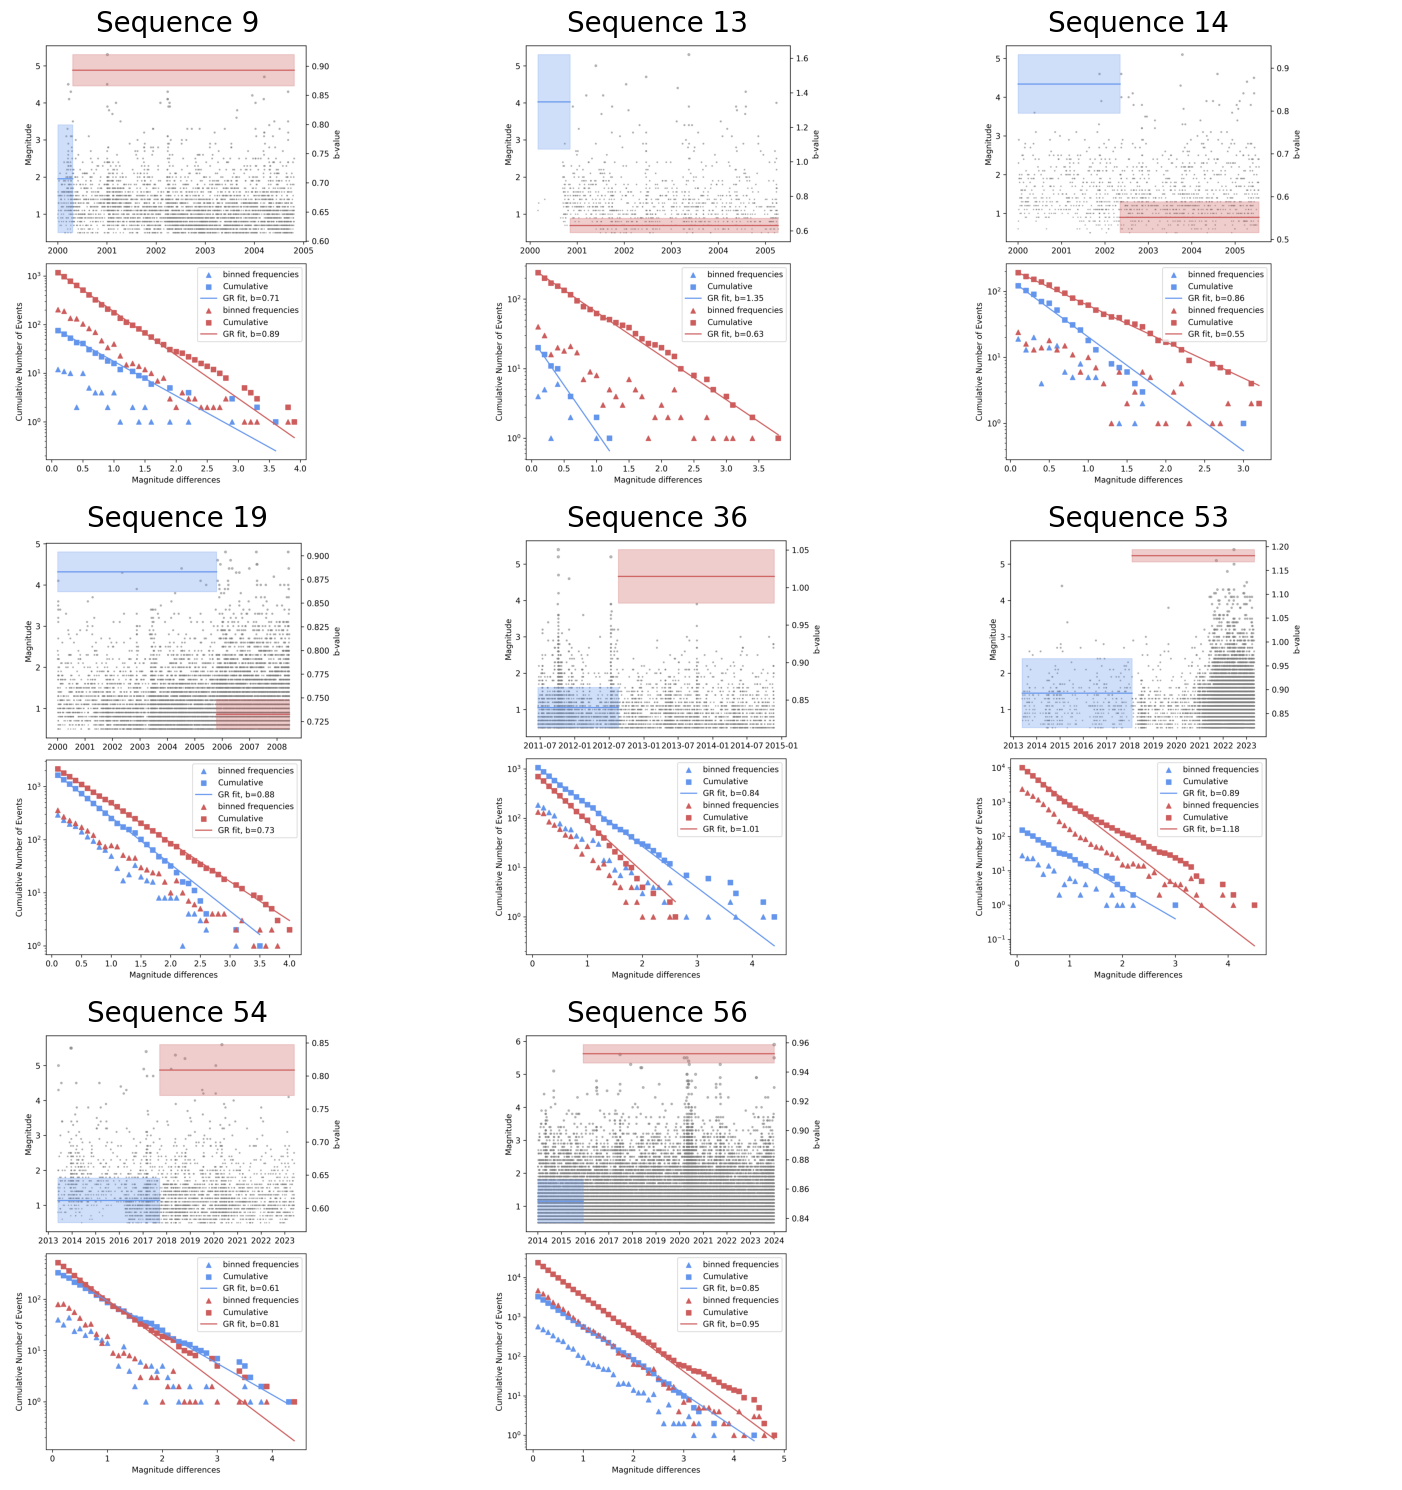

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import math

# List your image paths 
imgs = []
seq_nums = []
for restuls in results:
    sequence_num = restuls["sequence"]
    image_path = RESULT_DIR / f"images/sequence_{sequence_num}.png"
    imgs.append(image_path)
    seq_nums.append(sequence_num)
    # Open image
    images = [Image.open(image_path) for image_path in imgs]

# Assuming imgs and seq_nums are already defined
images = [Image.open(image_path) for image_path in imgs]

# Determine grid size (square-ish layout)
n = len(images)
cols = math.ceil(math.sqrt(n))
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))

# Flatten axes for easy iteration (handles 1D/2D cases)
axes = axes.flatten() if n > 1 else [axes]

for i, (img, seq) in enumerate(zip(images, seq_nums)):
    axes[i].imshow(img)
    axes[i].axis("off")
    axes[i].set_title(f"Sequence {seq}", fontsize=20)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()